# Attention / activation viz


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import interp

m = interp.load("google/gemma-3-12b-pt")
# cap = interp.run(m, "The cat sat on the")
cap = interp.run(m, "Which is bigger? A cat, B car, C bus ")

print(cap.tokens)

['<bos>', 'Which', ' is', ' bigger', '?', ' A', ' cat', ',', ' B', ' car', ',', ' C', ' bus', ' ']


## Shapes

`cap.attn` is `[n_layers, n_heads, seq, seq]`. For gpt2-small that's `12 layers x 12 heads`. `cap.attn[layer, head]` is one head's `[query, key]` matrix.

In [18]:
print("n_layers:", m.cfg.n_layers)
print("n_heads: ", m.cfg.n_heads)
print("attn:    ", cap.attn.shape, "[layer, head, query, key]")
print("logits:  ", cap.logits.shape, "[seq, vocab]")


n_layers: 48
n_heads:  16
attn:     (48, 16, 14, 14) [layer, head, query, key]
logits:   (14, 262208) [seq, vocab]


  0%|          | 0/10 [00:00<?, ?it/s]

18.65%  '\n\n'
15.90%  '1'
10.80%  '2'
 7.56%  '3'
 5.67%  '4'
 4.93%  '<strong>'
 4.74%  '\n'
 3.21%  '5'
 2.26%  '<start_of_image>'
 2.08%  '6'


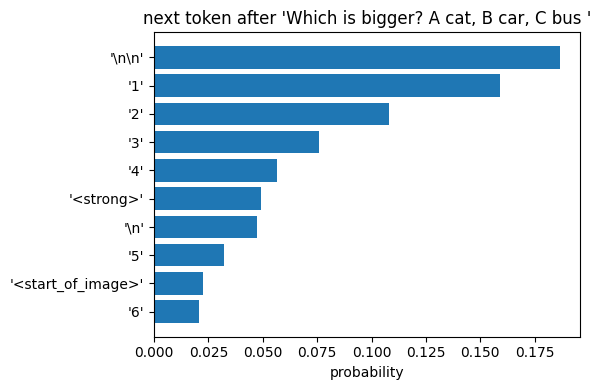

 10%|█         | 1/10 [00:07<01:07,  7.55s/it]

21.11%  'What'
20.22%  'Which'
 6.89%  'How'
 4.70%  'A'
 2.63%  'The'
 2.37%  'Is'
 2.15%  'I'
 2.13%  'Who'
 1.57%  'This'
 1.51%  'If'


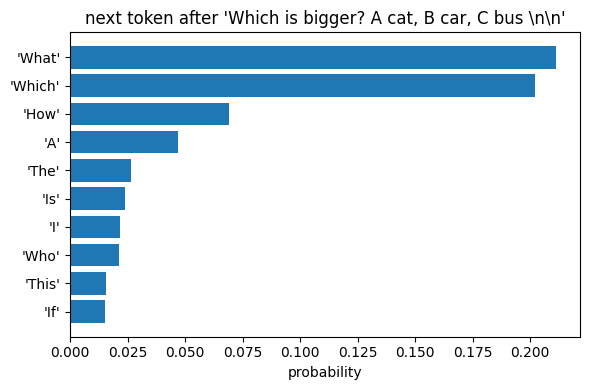

 20%|██        | 2/10 [00:08<00:31,  3.93s/it]

40.86%  ' is'
 5.73%  ' color'
 5.60%  ' do'
 4.63%  ' are'
 4.47%  ' does'
 4.40%  "'"
 3.33%  ' shape'
 2.73%  ' colour'
 2.58%  ' comes'
 2.26%  ' time'


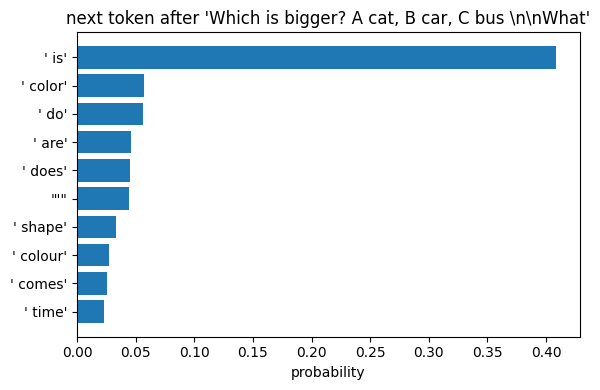

 30%|███       | 3/10 [00:10<00:19,  2.83s/it]

36.22%  ' the'
25.15%  ' this'
 6.44%  ' a'
 6.41%  ' '
 4.48%  ' your'
 3.32%  ' bigger'
 2.05%  ' it'
 1.40%  ' my'
 1.00%  ' an'
 0.76%  ' in'


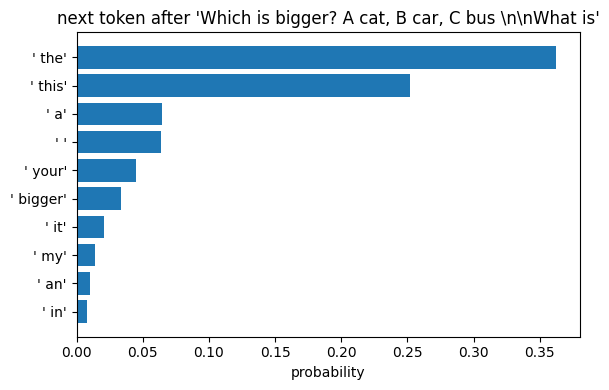

 40%|████      | 4/10 [00:12<00:13,  2.32s/it]

18.61%  ' name'
 5.10%  ' color'
 4.02%  ' biggest'
 3.52%  ' smallest'
 3.45%  ' opposite'
 3.40%  ' number'
 2.98%  ' shape'
 2.88%  ' time'
 2.86%  ' capital'
 2.64%  ' first'


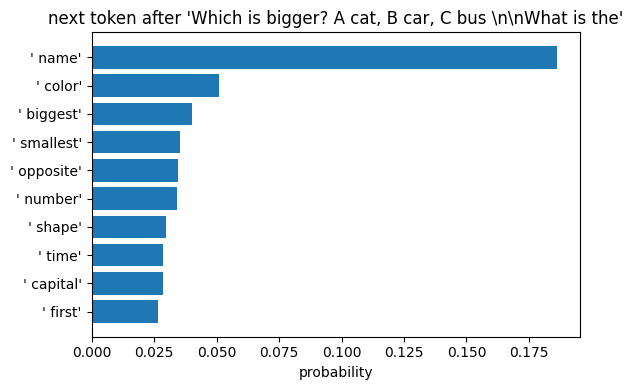

 50%|█████     | 5/10 [00:13<00:09,  1.93s/it]

93.78%  ' of'
 4.14%  ' for'
 0.50%  ' given'
 0.28%  '?'
 0.11%  ' that'
 0.09%  ' the'
 0.09%  ' if'
 0.08%  ' on'
 0.07%  ' and'
 0.06%  ' this'


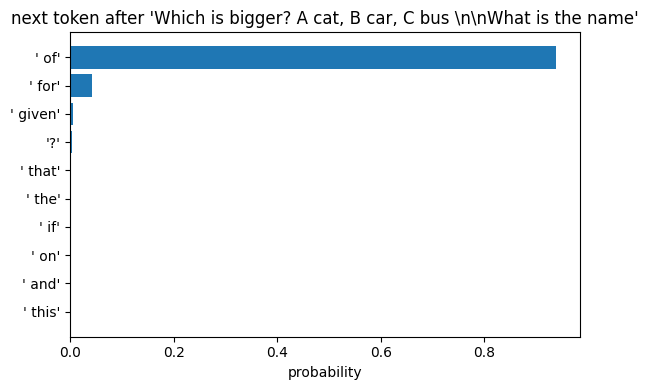

 60%|██████    | 6/10 [00:14<00:06,  1.68s/it]

41.74%  ' this'
39.71%  ' the'
 3.27%  ' a'
 3.26%  ' our'
 2.52%  ' your'
 2.09%  ' these'
 1.36%  ' my'
 0.30%  ' that'
 0.29%  ' all'
 0.27%  ' an'


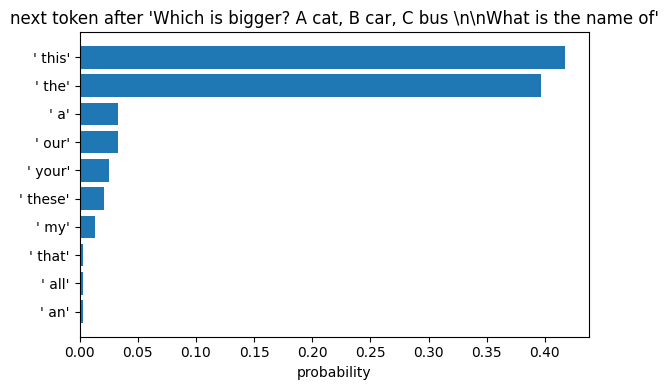

 70%|███████   | 7/10 [00:15<00:04,  1.53s/it]

15.88%  ' animal'
15.09%  ' shape'
 7.46%  ' fruit'
 2.99%  '?'
 2.60%  ' number'
 2.13%  ' food'
 2.10%  ' country'
 2.10%  ' vehicle'
 2.06%  ' place'
 1.76%  ' instrument'


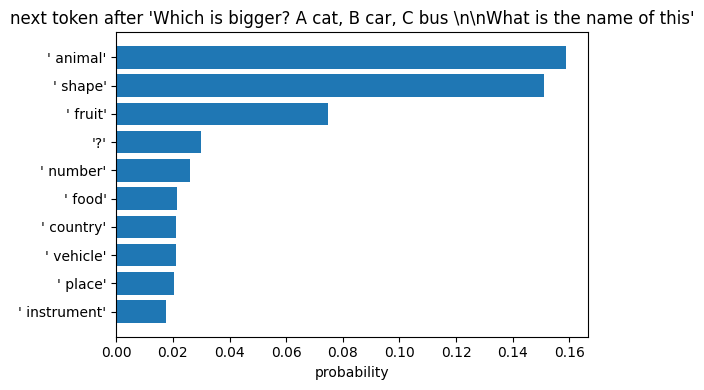

 80%|████████  | 8/10 [00:17<00:03,  1.71s/it]

87.25%  '?'
 3.11%  '\n\n'
 2.07%  ' '
 1.60%  ' ?'
 0.94%  '.'
 0.83%  ':'
 0.51%  ' in'
 0.48%  ','
 0.30%  ' that'
 0.24%  '<start_of_image>'


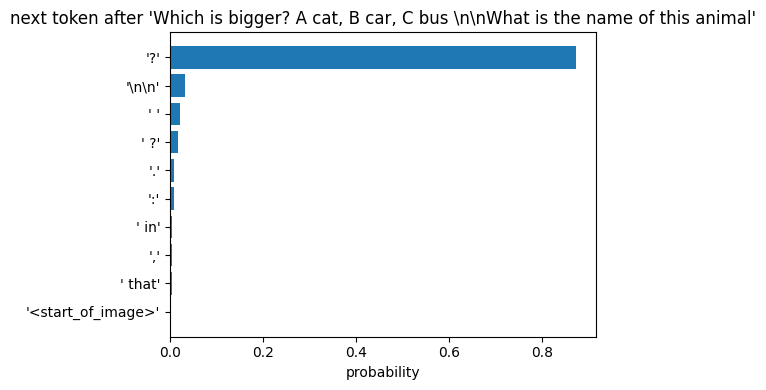

 90%|█████████ | 9/10 [00:30<00:05,  5.08s/it]

54.23%  '\n\n'
20.36%  ' '
 8.11%  ' A'
 5.66%  '<start_of_image>'
 1.71%  '  '
 0.82%  ' ('
 0.80%  '\n'
 0.68%  ' It'
 0.52%  ' Is'
 0.48%  ' a'


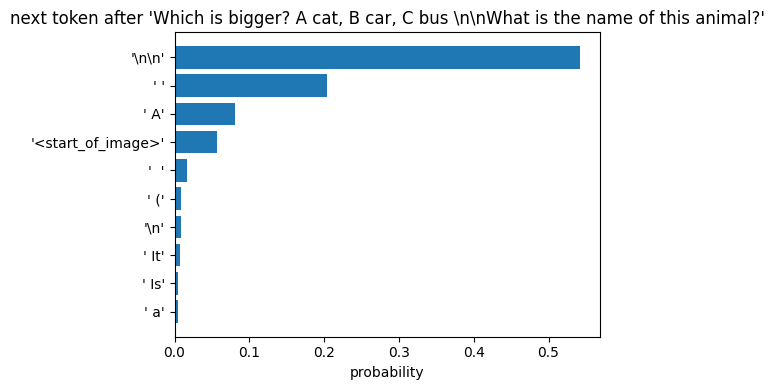

100%|██████████| 10/10 [00:34<00:00,  3.42s/it]


In [ ]:
from tqdm import tqdm

caps = []
text =  "Which is bigger? A cat, B car, C bus "
for _ in tqdm(range(10)):
    cap = interp.run(m, text)

    top = interp.predict(m, cap, k=10)

    toks = [t for t, _ in top][::-1]
    ps = [p for _, p in top][::-1]
    plt.figure(figsize=(6, 4))
    plt.barh(range(len(toks)), ps)
    plt.yticks(range(len(toks)), [repr(t) for t in toks])
    plt.xlabel("probability")
    plt.title(f"next token after {cap.prompt!r}")
    plt.tight_layout()
    plt.show()


    next_tok = m.to_single_str_token(int(cap.logits[-1].argmax()))
    text = text + next_tok
    caps.append(cap)


In [23]:
text



'Which is bigger? A cat, B car, C bus \n\nWhat is the name of this animal?\n\n'

## Predict the next token

`cap.logits[-1]` is the distribution over the vocab for the position *after* the last token. `interp.predict` softmaxes it and returns the top-k.

18.65%  '\n\n'
15.90%  '1'
10.80%  '2'
 7.56%  '3'
 5.67%  '4'
 4.93%  '<strong>'
 4.74%  '\n'
 3.21%  '5'
 2.26%  '<start_of_image>'
 2.08%  '6'


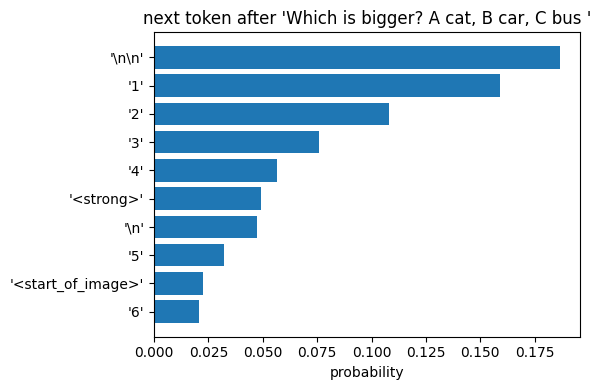

## One head's attention

Row = query (attending from), column = key (attended to). Causal, so it's lower-triangular.

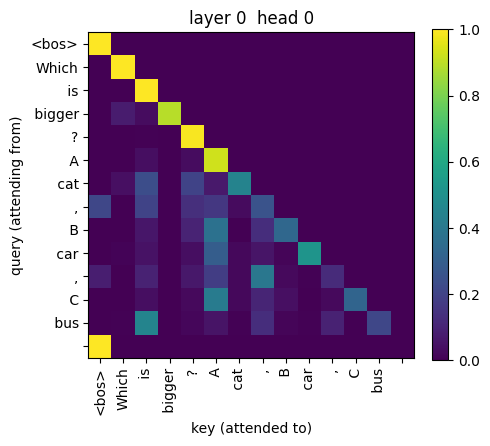

In [20]:
layer, head = 0, 0
A = cap.attn[layer, head]

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(A, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(cap.tokens)))
ax.set_xticklabels(cap.tokens, rotation=90)
ax.set_yticks(range(len(cap.tokens)))
ax.set_yticklabels(cap.tokens)
ax.set_xlabel("key (attended to)")
ax.set_ylabel("query (attending from)")
ax.set_title(f"layer {layer}  head {head}")
fig.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

## Every head in a layer

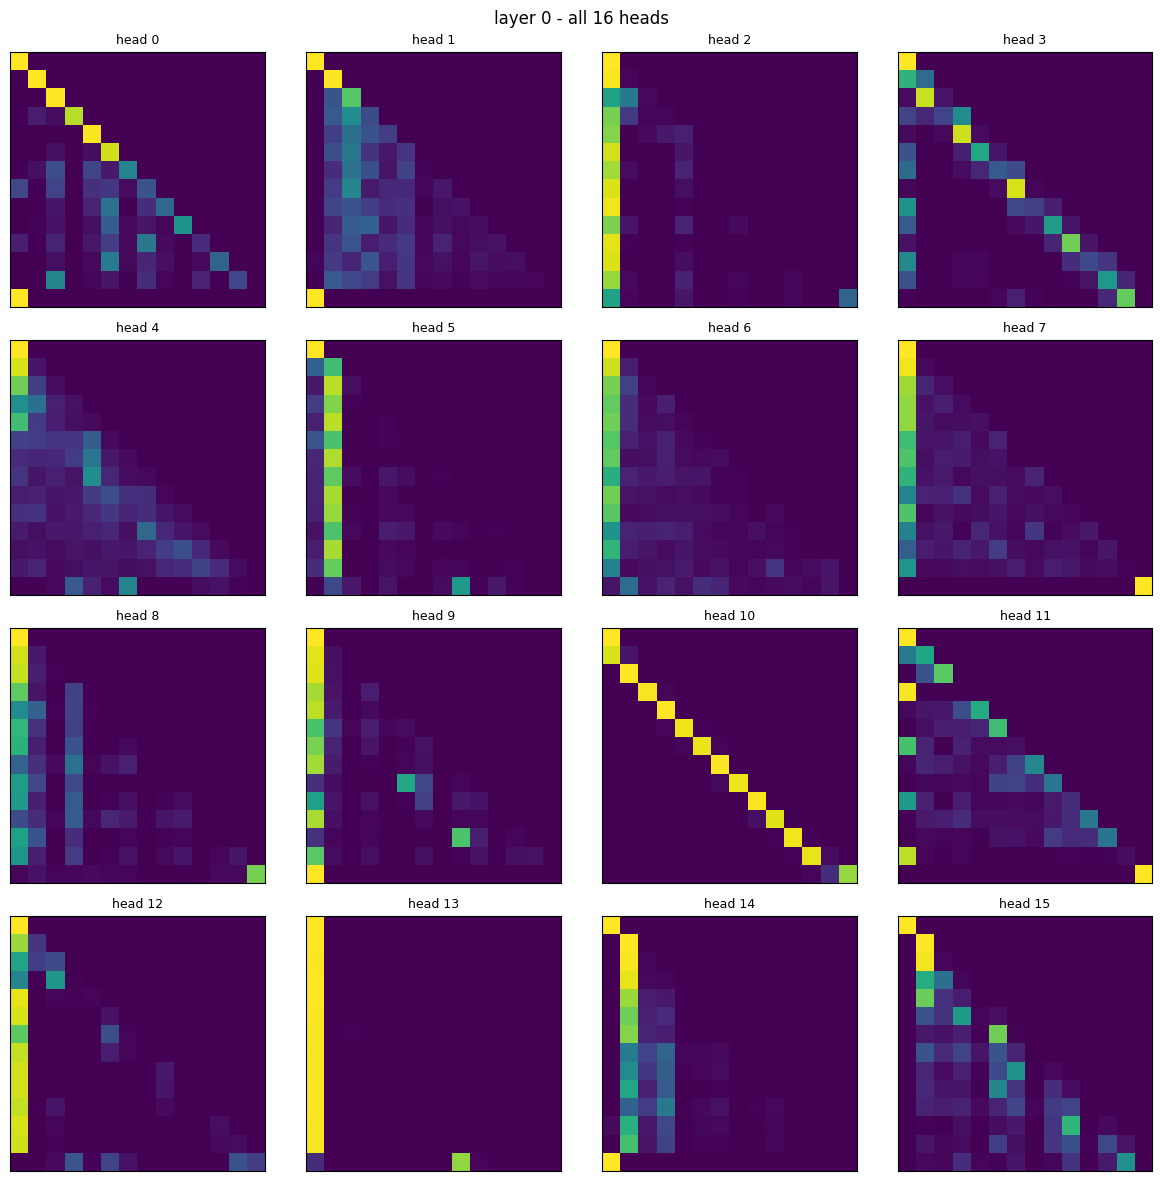

In [21]:
layer = 0
nh = m.cfg.n_heads
cols = 4
rows = (nh + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
for h, ax in enumerate(axes.flat):
    if h < nh:
        ax.imshow(cap.attn[layer, h], cmap="viridis", vmin=0, vmax=1)
        ax.set_title(f"head {h}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(f"layer {layer} - all {nh} heads")
plt.tight_layout()
plt.show()


## Activations

Any named activation via `interp.act(cap, name, layer)`. Here the residual stream after layer 6, `[seq, d_model]`.

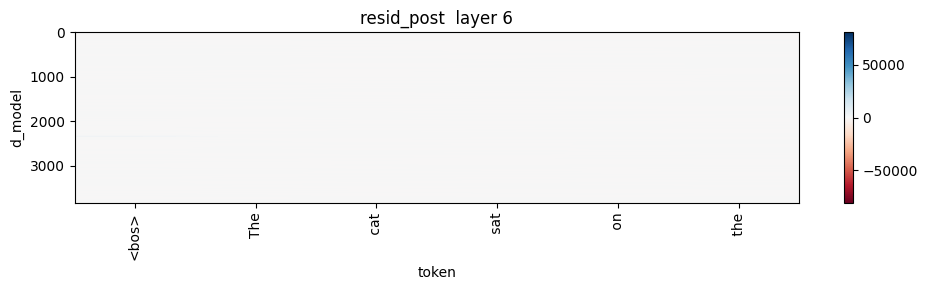

In [14]:
r = interp.act(cap, "resid_post", 6)  # [seq, d_model]
lim = np.abs(r).max()

plt.figure(figsize=(10, 3))
plt.imshow(r.T, aspect="auto", cmap="RdBu", vmin=-lim, vmax=lim)
plt.xticks(range(len(cap.tokens)), cap.tokens, rotation=90)
plt.xlabel("token")
plt.ylabel("d_model")
plt.title("resid_post  layer 6")
plt.colorbar()
plt.tight_layout()
plt.show()

### Tip: list every activation name in the cache

`cap.cache` is the raw TransformerLens `ActivationCache`. Keys you can pass to `interp.act`:

In [16]:
for k in list(cap.cache.keys()):
    print(k, tuple(cap.cache[k].shape))

hook_embed (1, 6, 3840)
blocks.0.hook_resid_pre (1, 6, 3840)
blocks.0.ln1.hook_scale (1, 6, 1)
blocks.0.ln1.hook_normalized (1, 6, 3840)
blocks.0.attn.hook_q (1, 6, 16, 256)
blocks.0.attn.hook_k (1, 6, 8, 256)
blocks.0.attn.hook_v (1, 6, 8, 256)
blocks.0.attn.q_norm.hook_scale (96, 1)
blocks.0.attn.q_norm.hook_normalized (96, 256)
blocks.0.attn.k_norm.hook_scale (48, 1)
blocks.0.attn.k_norm.hook_normalized (48, 256)
blocks.0.attn.hook_rot_q (1, 6, 16, 256)
blocks.0.attn.hook_rot_k (1, 6, 8, 256)
blocks.0.attn.hook_attn_scores (1, 16, 6, 6)
blocks.0.attn.hook_pattern (1, 16, 6, 6)
blocks.0.attn.hook_z (1, 6, 16, 256)
blocks.0.ln1_post.hook_scale (1, 6, 1)
blocks.0.ln1_post.hook_normalized (1, 6, 3840)
blocks.0.hook_attn_out (1, 6, 3840)
blocks.0.hook_resid_mid (1, 6, 3840)
blocks.0.ln2.hook_scale (1, 6, 1)
blocks.0.ln2.hook_normalized (1, 6, 3840)
blocks.0.mlp.hook_pre (1, 6, 15360)
blocks.0.mlp.hook_pre_linear (1, 6, 15360)
blocks.0.mlp.hook_post (1, 6, 15360)
blocks.0.ln2_post.hook_sc